In [1]:
import time
from functools import partial
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import optax

# Set a random seed for reproducibility
key = jax.random.PRNGKey(42)

## Problem Overview: 1D Ordinary Differential Equation

We are using a Physics-Informed Neural Network (PINN) to solve the following first-order ordinary differential equation:

$$\frac{dy}{dx} = x$$

### Domain and Conditions
- **Domain**: $x \in [0, 1]$
- **Initial Condition**: $y(0) = 0$

### Exact Solution
The analytical solution for this specific problem is:
$$y(x) = \frac{x^2}{2}$$

In [2]:
def exact_solution(x):
    return (x**2)/2

def plot_result(i, x_physics_batch, x_boundary, x_test_batch, y_exact_batch, y_test_batch):
    test_error = jnp.mean(jnp.abs(y_test_batch - y_exact_batch) / y_exact_batch.std())
    plt.figure(figsize=(8,3))
    plt.scatter(x_physics_batch[:,0], jnp.zeros_like(x_physics_batch)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
    plt.scatter(x_boundary, 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point (x=0)")
    plt.plot(x_test_batch[:,0], y_exact_batch[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
    plt.plot(x_test_batch[:,0], y_test_batch[:,0], label="PINN solution", color="tab:green")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Step {i} | Relative L1 Error: {test_error:.2%}")
    plt.legend()
    plt.show()

In [3]:
class FCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        keys = jax.random.split(key, len(layer_sizes)-1)
        parameters = [FCN._random_layer_parameters(k, m, n)
                      for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:])]
        return parameters

    @staticmethod
    def _random_layer_parameters(key, m, n):
        W_key, b_key = jax.random.split(key)
        v = jnp.sqrt(1/m)
        W = jax.random.uniform(W_key, (n, m), minval=-v, maxval=v)
        b = jax.random.uniform(b_key, (n,), minval=-v, maxval=v)
        return W, b

    @staticmethod
    def forward(parameters, x):
        activation_fn = jnp.tanh
        for W, b in parameters[:-1]:
            x = activation_fn(jnp.dot(W, x) + b)
        W_last, b_last = parameters[-1]
        y = jnp.dot(W_last, x) + b_last
        return y

In [4]:
def trapezoidal_integral(y_values, x_values):
    """Vectorized trapezoidal rule for JAX."""
    dx = x_values[1] - x_values[0]
    # Calculate trapezoid areas: (y_i + y_{i+1})/2 * dx
    mid_points = (y_values[:-1] + y_values[1:]) / 2.0
    # Cumulative sum to get the integral at each point
    integral = jnp.cumsum(mid_points * dx)
    # Prepend 0 so the integral at the first point (x=0) is 0
    return jnp.concatenate([jnp.array([0.0]), integral])

In [5]:
def PINN_loss_batch(parameters, x_boundary, x_physics_batch, network):
    # Ensure x_physics_batch is 1D for the integrator
    x_vals = x_physics_batch.squeeze()

    # 1. Network prediction (The NN represents y(x) directly)
    y_pred = jax.vmap(network.forward, in_axes=(None, 0))(parameters, x_physics_batch).squeeze()

    # 2. RHS Integration: Integrate the function 'x' from 0 to x
    # For y' = x, the RHS is the coordinate itself
    rhs_values = x_vals
    integral_approx = trapezoidal_integral(rhs_values, x_vals)

    # 3. Integral Residual: y(x) = y(0) + integral
    y0 = 0.0
    residual = y_pred - (y0 + integral_approx)

    return jnp.mean(residual**2)

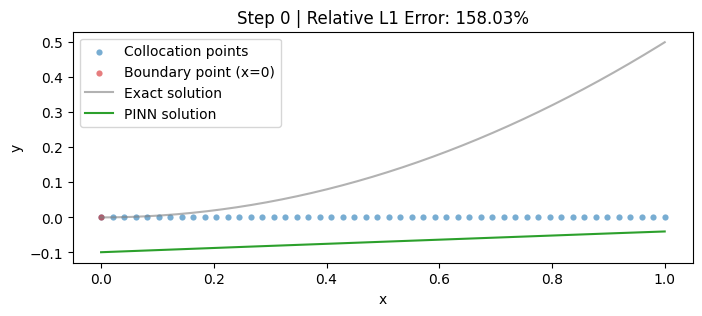

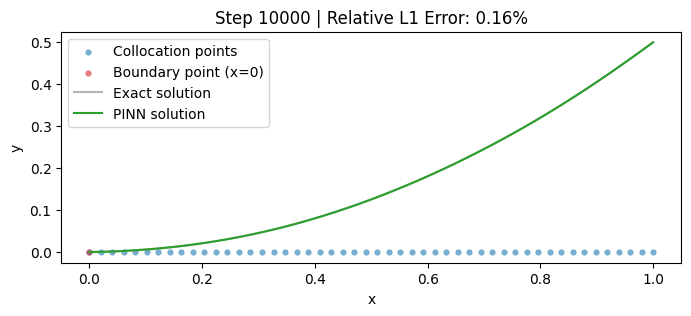

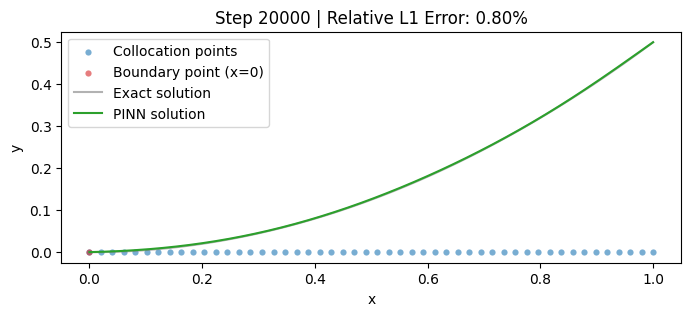

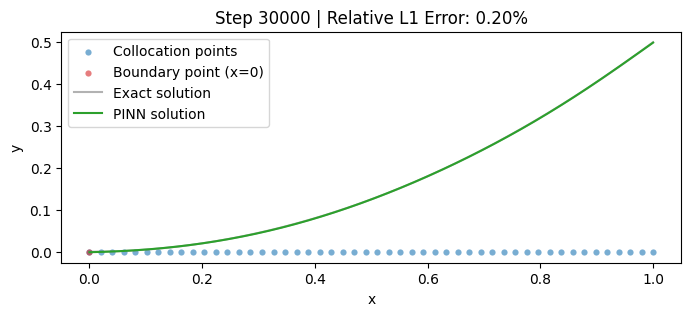

In [8]:
@partial(jax.jit, static_argnums=(1, 5))
def PINN_step(opt_state, optimiser, parameters, x_boundary, x_physics_batch, network):
    loss, grads = jax.value_and_grad(PINN_loss_batch, argnums=0)(
        parameters, x_boundary, x_physics_batch, network)
    updates, opt_state = optimiser.update(grads, opt_state, parameters)
    parameters = optax.apply_updates(parameters, updates)
    return loss, opt_state, parameters

# Setup and Execution
x_boundary = jnp.array([0.0])
x_physics_batch = jnp.linspace(0, 1, 50).reshape(-1, 1)
x_test_batch = jnp.linspace(0, 1, 300).reshape(-1, 1)
y_exact_batch = jax.vmap(exact_solution)(x_test_batch)

network = FCN
parameters = network.init_parameters(key, [1, 32, 32, 1])
optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(parameters)

for i in range(30001):
    loss, opt_state, parameters = PINN_step(opt_state, optimiser, parameters, x_boundary, x_physics_batch, network)
    if i % 10000 == 0:
        # Method 3: NN output is the solution directly
        y_test_batch = jax.vmap(network.forward, in_axes=(None, 0))(parameters, x_test_batch)
        plot_result(i, x_physics_batch, x_boundary, x_test_batch, y_exact_batch, y_test_batch)

## Inverse Problem Overview: Parameter Estimation

In an *inverse problem*, instead of solving for the state of the system given known parameters, we use observed data to infer unknown parameters of the system. Here, we aim to estimate an unknown parameter (which we'll call `alpha`) in our ODE $\frac{dy}{dx} = \alpha x$, given some noisy measurements of $y(x)$.

### Problem Statement
- **Governing Equation**: $\frac{dy}{dx} = \alpha x$
- **Domain**: $x \in [0, 1]$
- **Initial Condition**: $y(0) = 0$

### Goal
Infer the value of $\alpha$ using observed data, knowing that the true value of $\alpha$ is $1.0$ (leading to the exact solution $y(x) = \frac{x^2}{2}$).

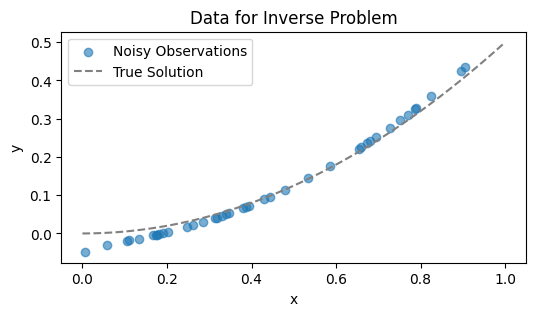

In [9]:
# 1. Define the updated exact solution for data generation
def exact_solution(x):
    return (x**2)/2

# 2. Generate noisy observational data
key, subkey = jax.random.split(key)
# Randomly sample 40 points in the domain [0, 1]
x_obs = (jax.random.uniform(subkey, (40, 1)))
# Generate true y values and add 5% Gaussian noise
y_obs = exact_solution(x_obs) + 0.02 * jax.random.normal(subkey, (40, 1))

# Visualize the data the PINN will learn from
plt.figure(figsize=(6, 3))
plt.scatter(x_obs, y_obs, label="Noisy Observations", color="tab:blue", alpha=0.6)
x_plot = jnp.linspace(0, 1, 100)
plt.plot(x_plot, exact_solution(x_plot), label="True Solution", color="grey", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Data for Inverse Problem")
plt.show()

Step 0 | Loss: 4.4680e-02 | Alpha Estimate: 0.0010
Step 2000 | Loss: 2.2299e-02 | Alpha Estimate: 0.4714
Step 4000 | Loss: 2.2296e-02 | Alpha Estimate: 0.4719
Step 6000 | Loss: 2.2295e-02 | Alpha Estimate: 0.4715
Step 8000 | Loss: 2.2294e-02 | Alpha Estimate: 0.4725
Step 10000 | Loss: 2.2293e-02 | Alpha Estimate: 0.4730
Step 12000 | Loss: 2.2292e-02 | Alpha Estimate: 0.4729
Step 14000 | Loss: 2.2292e-02 | Alpha Estimate: 0.4735


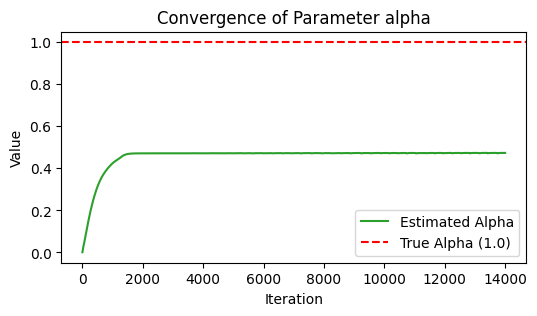

In [10]:
def PINN_inverse_loss_batch(params_and_alpha, x_obs, y_obs, x_physics_batch, network):
    parameters, alpha = params_and_alpha
    x_vals = x_physics_batch.squeeze()

    # 1. Prediction: Network represents y(x) directly
    y_pred = jax.vmap(network.forward, in_axes=(None, 0))(parameters, x_physics_batch).squeeze()

    # 2. Integral Identity: y(x) = y0 + integral_0^x (alpha * s) ds
    y0 = 0.0
    rhs_values = alpha * x_vals
    integral_approx = trapezoidal_integral(rhs_values, x_vals)

    # 3. Physics Residual
    loss_physics = jnp.mean((y_pred - (y0 + integral_approx))**2)

    # 4. Data Loss: match observations (Direct NN output)
    y_pred_obs = jax.vmap(network.forward, in_axes=(None, 0))(parameters, x_obs).squeeze()
    loss_data = jnp.mean((y_pred_obs - y_obs)**2)

    return loss_physics + 1e0 * loss_data

# 3. Define JIT-compiled Step Function
@partial(jax.jit, static_argnums=(1, 6))
def inverse_step(opt_state, optimiser, params_and_alpha, x_obs, y_obs, x_physics_batch, network):
    """Updates PINN parameters and the unknown alpha using the optax optimiser"""

    # get loss and gradient over the combined parameters (network weights + alpha)
    loss, grads = jax.value_and_grad(PINN_inverse_loss_batch, argnums=0)(
        params_and_alpha, x_obs, y_obs, x_physics_batch, network)

    # apply parameter update
    updates, opt_state = optimiser.update(grads, opt_state, params_and_alpha)
    params_and_alpha = optax.apply_updates(params_and_alpha, updates)

    return loss, opt_state, params_and_alpha

# 4. Initialize and Run Training
network = FCN
parameters = network.init_parameters(key, [1, 32, 32, 1])
alpha_init = jnp.array(0.0) # Initial guess
params_and_alpha = (parameters, alpha_init)

optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(params_and_alpha)

alphas = []
for i in range(14001):
    loss, opt_state, params_and_alpha = inverse_step(
        opt_state, optimiser, params_and_alpha, x_obs, y_obs, x_physics_batch, network)

    current_alpha = params_and_alpha[1]
    alphas.append(current_alpha)

    if i % 2000 == 0:
        # In Method 3, the NN represents the solution directly
        y_test_pred = jax.vmap(network.forward, in_axes=(None, 0))(
            params_and_alpha[0], x_test_batch).squeeze()
        print(f"Step {i} | Loss: {loss:.4e} | Alpha Estimate: {current_alpha:.4f}")

# Plot convergence
plt.figure(figsize=(6, 3))
plt.plot(alphas, label="Estimated Alpha", color="tab:green")
plt.axhline(y=1.0, color="red", linestyle="--", label="True Alpha (1.0)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.legend()
plt.title("Convergence of Parameter alpha")
plt.show()